In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import kruskal

In [3]:
df = pd.read_csv(r"C:\Users\cmkua\Downloads\LIBS_acoustic_meta_sheet_v4_293.csv")

print(df.shape)
df.head()

(293, 26)


,File Name,Formation,Member,Onset (s),Slope (dB/s),R^2,Drop Time (s),C2 (dB),Spectral Centroid (Hz),Spectral Bandwidth (Hz),...,Total FFT Power,Recovery Method,Flagged,Sample Rate (Hz),Peak Time (s),Peak-Onset Lag (ms),Pass2 Expected Time (s),Region,Dataset Source,Processing Version
0,scam_0037_0670224261_699_ca0_scam01037_hedgeho...,Maaz,Nataani,0.07044,-2074.302191,0.936293,0.003857,12.181746,10066.146470,11260.038700,...,3.819488e+10,NaN,NaN,NaN,NaN,NaN,NaN,Crater Floor,Crater Floor,NaN
1,scam_0037_0670224376_725_ca0_scam01037_hedgeho...,Maaz,Nataani,0.07063,-413.173826,0.659547,0.019362,11.841660,10566.099810,11546.299620,...,3.201470e+10,very wide soft,NaN,NaN,NaN,NaN,NaN,Crater Floor,Crater Floor,NaN
2,scam_0051_0671472287_263_ca0_scam04051_tselhba...,Maaz,Nataani,0.07015,-1285.051556,0.867640,0.006225,11.981924,7981.686832,8823.743572,...,1.112285e+11,NaN,NaN,NaN,NaN,NaN,NaN,Crater Floor,Crater Floor,NaN
3,scam_0051_0671472426_181_ca0_scam04051_tselhba...,Maaz,Nataani,0.07017,-5037.960485,0.942960,0.001588,16.838709,10981.154410,11915.544610,...,2.579335e+10,NaN,NaN,NaN,NaN,NaN,NaN,Crater Floor,Crater Floor,NaN
4,scam_0071_0673238205_695_ca0_scam05071_hadahas...,Maaz,Nataani,0.07146,-1765.439119,0.906672,0.004531,11.806206,9914.760509,10870.284900,...,4.207207e+10,Original,NaN,NaN,NaN,NaN,NaN,Crater Floor,Crater Floor,NaN


In [6]:
print(df.columns.tolist())

['File Name', 'Formation', 'Member', 'Onset (s)', 'Slope (dB/s)', 'R^2', 'Drop Time (s)', 'C2 (dB)', 'Spectral Centroid (Hz)', 'Spectral Bandwidth (Hz)', 'Peak Frequency (Hz)', 'Rolloff 85% (Hz)', 'Low Power 1-10 kHz', 'High Power 10-30 kHz', 'High/Low Ratio', 'High Frequency Fraction', 'Total FFT Power', 'Recovery Method', 'Flagged', 'Sample Rate (Hz)', 'Peak Time (s)', 'Peak-Onset Lag (ms)', 'Pass2 Expected Time (s)', 'Region', 'Dataset Source', 'Processing Version']


In [7]:
print(df["Region"].value_counts())

Region
Crater Floor    185
Upper Fan        55
Delta            53
Name: count, dtype: int64


In [8]:
metrics = [
    "Slope (dB/s)",
    "C2 (dB)",
    "Spectral Centroid (Hz)",
    "Spectral Bandwidth (Hz)",
    "Peak Frequency (Hz)",
    "Rolloff 85% (Hz)",
    "High Frequency Fraction",
    "High/Low Ratio"
]

In [9]:
summary = (
    df.groupby("Region")[metrics]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

summary

Slope (dB/s)                            C2 (dB)                \
                    count     mean   median      std   count   mean median   
Region                                                                       
Crater Floor          185 -3881.11 -3019.39  3370.03     185  10.80  12.28   
Delta                  53 -8363.33 -7030.84  6111.03      53  15.41  16.93   
Upper Fan              55 -8715.67 -6126.00  9337.22      55  15.26  16.03   

                   Spectral Centroid (Hz)           ... Rolloff 85% (Hz)  \
               std                  count     mean  ...           median   
Region                                              ...                    
Crater Floor  6.08                    185  8496.64  ...           9700.0   
Delta         6.15                     53  6890.86  ...           9100.0   
Upper Fan     6.16                     55  7298.69  ...           9500.0   

                      High Frequency Fraction                     \
                  std                   count  mean median   std   
Region                                                             
Crater Floor  8561.15                     185  0.07   0.06  0.05   
Delta         2058.57                      53  0.13   0.11  0.08   
Upper Fan     3585.83                      55  0.16   0.13  0.13   

             High/Low Ratio                     
                      count  mean median   std  
Region                                          
Crater Floor            185  0.15   0.11  0.17  
Delta                    53  0.17   0.13  0.17  
Upper Fan                55  0.24   0.14  0.44  

[3 rows x 32 columns]

In [10]:
from scipy.stats import kruskal

results = []

for metric in metrics:

    crater = df[df["Region"] == "Crater Floor"][metric].dropna()
    delta = df[df["Region"] == "Delta"][metric].dropna()
    upper = df[df["Region"] == "Upper Fan"][metric].dropna()

    H, p = kruskal(crater, delta, upper)

    results.append({
        "Metric": metric,
        "H": H,
        "p-value": p
    })

kw = (
    pd.DataFrame(results)
      .sort_values("p-value")
)

kw

,Metric,H,p-value
3,Spectral Bandwidth (Hz),154.257485,3.187224e-34
6,High Frequency Fraction,81.405825,2.103535e-18
1,C2 (dB),64.351378,1.062370e-14
0,Slope (dB/s),60.215828,8.400382e-14
2,Spectral Centroid (Hz),19.268888,6.543560e-05
4,Peak Frequency (Hz),13.519818,1.159335e-03
5,Rolloff 85% (Hz),5.727259,5.706129e-02
7,High/Low Ratio,5.431561,6.615332e-02


In [12]:
N = len(df)
k = df["Region"].nunique()

kw["Epsilon Squared"] = (
    (kw["H"] - k + 1) /
    (N - k)
)

kw.round(4)

,Metric,H,p-value,Epsilon Squared
3,Spectral Bandwidth (Hz),154.2575,0.0000,0.5250
6,High Frequency Fraction,81.4058,0.0000,0.2738
1,C2 (dB),64.3514,0.0000,0.2150
0,Slope (dB/s),60.2158,0.0000,0.2007
2,Spectral Centroid (Hz),19.2689,0.0001,0.0595
4,Peak Frequency (Hz),13.5198,0.0012,0.0397
5,Rolloff 85% (Hz),5.7273,0.0571,0.0129
7,High/Low Ratio,5.4316,0.0662,0.0118


In [15]:
import scikit_posthocs as sp

pairwise_results = {}

for metric in metrics:
    pairwise_results[metric] = sp.posthoc_dunn(
        df,
        val_col=metric,
        group_col="Region",
        p_adjust="holm"
    )

In [16]:
summary = []

for metric, table in pairwise_results.items():

    summary.append({
        "Metric": metric,
        "Crater Floor vs Delta":
            table.loc["Crater Floor","Delta"],

        "Crater Floor vs Upper Fan":
            table.loc["Crater Floor","Upper Fan"],

        "Delta vs Upper Fan":
            table.loc["Delta","Upper Fan"]
    })

pairwise_summary = (
    pd.DataFrame(summary)
      .set_index("Metric")
      .round(5)
)

pairwise_summary

,Crater Floor vs Delta,Crater Floor vs Upper Fan,Delta vs Upper Fan
Metric,,,
Slope (dB/s),0.00000,0.00000,0.31766
C2 (dB),0.00000,0.00000,0.51469
Spectral Centroid (Hz),0.00031,0.00815,0.39501
Spectral Bandwidth (Hz),0.00000,0.00000,0.36982
Peak Frequency (Hz),0.03833,0.00300,0.46580
Rolloff 85% (Hz),0.07105,0.40705,0.41420
High Frequency Fraction,0.00000,0.00000,0.67991
High/Low Ratio,0.40500,0.08586,0.47474


In [17]:
sig_table = pairwise_summary.copy()

for col in sig_table.columns:
    sig_table[col] = sig_table[col].apply(
        lambda x: "✓" if x < 0.05 else "✗"
    )

sig_table

,Crater Floor vs Delta,Crater Floor vs Upper Fan,Delta vs Upper Fan
Metric,,,
Slope (dB/s),✓,✓,✗
C2 (dB),✓,✓,✗
Spectral Centroid (Hz),✓,✓,✗
Spectral Bandwidth (Hz),✓,✓,✗
Peak Frequency (Hz),✓,✓,✗
Rolloff 85% (Hz),✗,✗,✗
High Frequency Fraction,✓,✓,✗
High/Low Ratio,✗,✗,✗


In [18]:
cf = df[df["Region"] == "Crater Floor"].copy()

print(cf["Formation"].value_counts())

Formation
Maaz      97
Seitah    88
Name: count, dtype: int64


In [19]:
from scipy.stats import kruskal

results = []

for metric in metrics:

    maaz = cf[cf["Formation"] == "Maaz"][metric].dropna()
    seitah = cf[cf["Formation"] == "Seitah"][metric].dropna()

    H, p = kruskal(maaz, seitah)

    results.append({
        "Metric": metric,
        "H": H,
        "p-value": p
    })

kw_form = (
    pd.DataFrame(results)
      .sort_values("p-value")
)

kw_form

,Metric,H,p-value
4,Peak Frequency (Hz),4.626958,0.031473
7,High/Low Ratio,0.868587,0.351347
0,Slope (dB/s),0.828075,0.362830
2,Spectral Centroid (Hz),0.435348,0.509376
3,Spectral Bandwidth (Hz),0.389462,0.532582
1,C2 (dB),0.088158,0.766532
6,High Frequency Fraction,0.029998,0.862494
5,Rolloff 85% (Hz),0.003024,0.956143


In [20]:
N = len(cf)
k = cf["Formation"].nunique()

kw_form["Epsilon Squared"] = (
    (kw_form["H"] - k + 1) /
    (N - k)
)

kw_form.round(4)

,Metric,H,p-value,Epsilon Squared
4,Peak Frequency (Hz),4.6270,0.0315,0.0198
7,High/Low Ratio,0.8686,0.3513,-0.0007
0,Slope (dB/s),0.8281,0.3628,-0.0009
2,Spectral Centroid (Hz),0.4353,0.5094,-0.0031
3,Spectral Bandwidth (Hz),0.3895,0.5326,-0.0033
1,C2 (dB),0.0882,0.7665,-0.0050
6,High Frequency Fraction,0.0300,0.8625,-0.0053
5,Rolloff 85% (Hz),0.0030,0.9561,-0.0054


In [21]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# ----------------------------
# Crater floor only
# ----------------------------
cf = df[df["Region"] == "Crater Floor"].copy()

print("Sample counts by member:")
print(cf["Member"].value_counts().sort_index())

# ----------------------------
# Metrics to analyze
# ----------------------------
metrics = [
    "Slope (dB/s)",
    "C2 (dB)",
    "Spectral Centroid (Hz)",
    "Spectral Bandwidth (Hz)",
    "Peak Frequency (Hz)",
    "Rolloff 85% (Hz)",
    "High Frequency Fraction",
    "High/Low Ratio"
]

# ----------------------------
# Kruskal-Wallis
# ----------------------------
results = []

members = sorted(cf["Member"].dropna().unique())

for metric in metrics:

    groups = [
        cf.loc[cf["Member"] == m, metric].dropna()
        for m in members
    ]

    H, p = kruskal(*groups)

    results.append({
        "Metric": metric,
        "H": H,
        "p-value": p
    })

kw_members = (
    pd.DataFrame(results)
    .sort_values("p-value")
)

# ----------------------------
# Effect size (epsilon squared)
# ----------------------------
N = len(cf)
k = len(members)

kw_members["Epsilon Squared"] = (
    (kw_members["H"] - k + 1) /
    (N - k)
)

kw_members = kw_members.round(4)

print("\n========== Kruskal-Wallis ==========\n")
print(kw_members)

# ----------------------------
# Dunn post hoc
# ----------------------------
print("\n========== Dunn Post Hoc (Holm corrected) ==========\n")

for metric in kw_members.loc[kw_members["p-value"] < 0.05, "Metric"]:

    print(f"\n\n===== {metric} =====")

    posthoc = sp.posthoc_dunn(
        cf,
        val_col=metric,
        group_col="Member",
        p_adjust="holm"
    )

    print(posthoc.round(4))

Sample counts by member:
Member
Artuby        7
Bastide      23
Caille       12
Cha'al       10
Content       8
Nataani      40
Rochette     29
Roubion      11
Undivided    45
Name: count, dtype: int64

========== Kruskal-Wallis ==========

                    Metric        H  p-value  Epsilon Squared
3  Spectral Bandwidth (Hz)  39.5727   0.0000           0.1794
2   Spectral Centroid (Hz)  27.4535   0.0006           0.1105
5         Rolloff 85% (Hz)  24.6314   0.0018           0.0945
6  High Frequency Fraction  23.9750   0.0023           0.0908
7           High/Low Ratio  22.0571   0.0048           0.0799
1                  C2 (dB)  20.4974   0.0086           0.0710
4      Peak Frequency (Hz)  19.1951   0.0139           0.0636
0             Slope (dB/s)  11.5471   0.1726           0.0202

========== Dunn Post Hoc (Holm corrected) ==========



===== Spectral Bandwidth (Hz) =====
           Artuby  Bastide  Caille  Cha'al  Content  Nataani  Rochette  \
Artuby     1.0000   0.9896  0.5755

In [22]:
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[metrics].corr(method="spearman")

corr.round(3)

,Slope (dB/s),C2 (dB),Spectral Centroid (Hz),Spectral Bandwidth (Hz),Peak Frequency (Hz),Rolloff 85% (Hz),High Frequency Fraction,High/Low Ratio
Slope (dB/s),1.000,-0.695,0.188,0.377,-0.084,0.139,-0.215,0.013
C2 (dB),-0.695,1.000,-0.148,-0.399,0.219,-0.177,0.430,-0.087
Spectral Centroid (Hz),0.188,-0.148,1.000,0.747,0.316,0.895,0.388,0.722
Spectral Bandwidth (Hz),0.377,-0.399,0.747,1.000,-0.052,0.681,-0.069,0.441
Peak Frequency (Hz),-0.084,0.219,0.316,-0.052,1.000,0.156,0.354,0.149
Rolloff 85% (Hz),0.139,-0.177,0.895,0.681,0.156,1.000,0.448,0.872
High Frequency Fraction,-0.215,0.430,0.388,-0.069,0.354,0.448,1.000,0.602
High/Low Ratio,0.013,-0.087,0.722,0.441,0.149,0.872,0.602,1.000


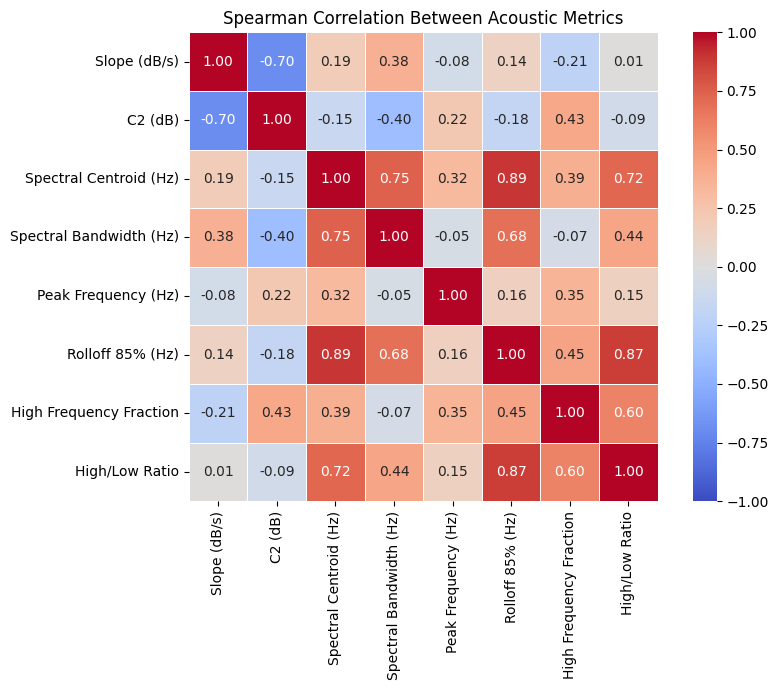

In [23]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Between Acoustic Metrics")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

X = df[metrics]

X_scaled = StandardScaler().fit_transform(X)

In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

scores = pca.fit_transform(X_scaled)

print("Explained variance:")
print(pca.explained_variance_ratio_)

Explained variance:
[0.45352988 0.21817864]


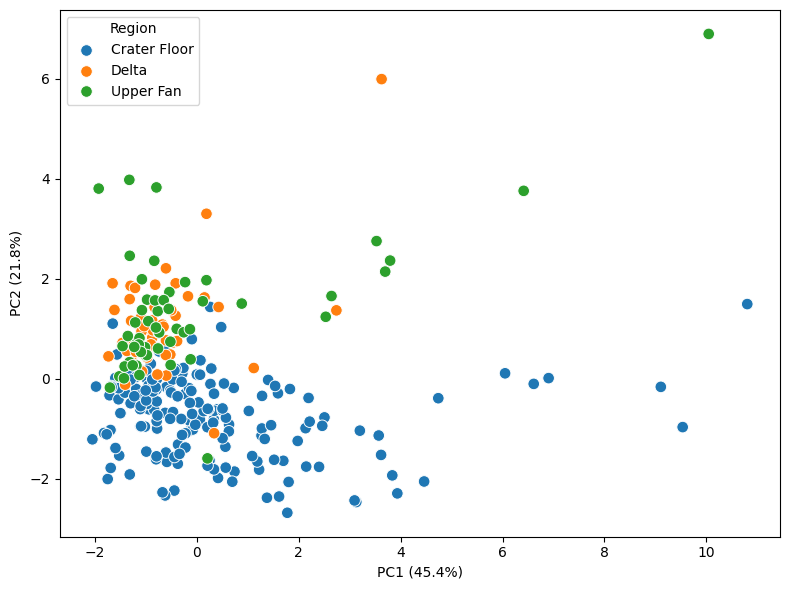

In [26]:
pca_df = pd.DataFrame({
    "PC1": scores[:,0],
    "PC2": scores[:,1],
    "Region": df["Region"]
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Region",
    s=70
)

plt.xlabel(f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)")
plt.ylabel(f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)")

plt.tight_layout()
plt.show()

In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=metrics,
    columns=["PC1", "PC2"]
)

loadings.round(3)

,PC1,PC2
Slope (dB/s),0.074,-0.463
C2 (dB),-0.092,0.466
Spectral Centroid (Hz),0.501,-0.080
Spectral Bandwidth (Hz),0.374,-0.402
Peak Frequency (Hz),0.357,0.216
Rolloff 85% (Hz),0.466,-0.151
High Frequency Fraction,0.303,0.508
High/Low Ratio,0.398,0.271


In [31]:
# ============================================================
# PERMANOVA + PERMDISP + PCoA BY REGION
# ============================================================

# Run this once if scikit-bio is not installed:
# %pip install scikit-bio

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
from skbio.stats.ordination import pcoa


# ------------------------------------------------------------
# 1. Prepare a complete dataset
# ------------------------------------------------------------

analysis_df = (
    df[["Region"] + metrics]
    .dropna()
    .reset_index(drop=True)
)

print("Samples included:", len(analysis_df))
print("\nSamples by region:")
print(analysis_df["Region"].value_counts())


# ------------------------------------------------------------
# 2. Standardize the acoustic metrics
#
# This is necessary because the variables use different units:
# dB/s, dB, Hz, fractions, and ratios.
# ------------------------------------------------------------

X = analysis_df[metrics]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ------------------------------------------------------------
# 3. Calculate Euclidean distances between recordings
# ------------------------------------------------------------

distance_array = squareform(
    pdist(X_scaled, metric="euclidean")
)

sample_ids = [f"sample_{i}" for i in range(len(analysis_df))]

distance_matrix = DistanceMatrix(
    distance_array,
    ids=sample_ids
)

grouping = pd.Series(
    analysis_df["Region"].values,
    index=sample_ids,
    name="Region"
)


# ------------------------------------------------------------
# 4. PERMANOVA
#
# Tests whether the overall multivariate acoustic signatures
# differ among Crater Floor, Delta, and Upper Fan.
# ------------------------------------------------------------

permanova_result = permanova(
    distance_matrix,
    grouping,
    permutations=9999
)

print("\n========== PERMANOVA ==========\n")
print(permanova_result)


# ------------------------------------------------------------
# 5. PERMDISP
#
# Checks whether the groups differ mainly because they have
# different within-group variability or dispersion.
# ------------------------------------------------------------

permdisp_result = permdisp(
    distance_matrix,
    grouping,
    permutations=9999
)

print("\n========== PERMDISP ==========\n")
print(permdisp_result)


# ------------------------------------------------------------
# 6. PCoA
#
# Places recordings in a low-dimensional space based on the
# same distance matrix used by PERMANOVA.
# ------------------------------------------------------------

pcoa_result = pcoa(distance_matrix)

coordinates = pcoa_result.samples.copy()
coordinates["Region"] = analysis_df["Region"].values

pc1_percent = 100 * pcoa_result.proportion_explained.iloc[0]
pc2_percent = 100 * pcoa_result.proportion_explained.iloc[1]

print("\nVariance represented by PCoA axes:")
print(f"PCoA 1: {pc1_percent:.2f}%")
print(f"PCoA 2: {pc2_percent:.2f}%")


# ------------------------------------------------------------
# 7. Plot PCoA
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=coordinates,
    x="PC1",
    y="PC2",
    hue="Region",
    s=65,
    alpha=0.80
)

plt.axhline(0, linewidth=0.7)
plt.axvline(0, linewidth=0.7)

plt.xlabel(f"PCoA 1 ({pc1_percent:.1f}%)")
plt.ylabel(f"PCoA 2 ({pc2_percent:.1f}%)")
plt.title("PCoA of SuperCam LIBS Acoustic Metrics")

plt.legend(title="Region")
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'skbio'

In [32]:
!pip install scikit-bio

  Using cached scikit_bio-0.7.3-cp314-cp314-win_amd64.whl.metadata (10 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached h5py-3.16.0-cp314-cp314-win_amd64.whl.metadata (3.1 kB)
  Using cached biom_format-2.1.17.tar.gz (11.7 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached array_api_compat-1.15.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached scikit_bio-0.7.3-cp314-cp314-win_amd64.whl (6.6 MB)
Using cached array_api_compat-1.15.0-py3-none-any.whl (79 kB)
Using cached h5py-3.16.0-cp314-cp314-win_amd64.whl (3.2 MB)
Using cached natsort-8.4.0-py3-none-any.whl (38 kB)
Using cached click-8.4.2-py3-none-a

  error: subprocess-exited-with-error
  
  exit code: 1
  
  [296 lines of output]
  [1/3] Cythonizing biom/_filter.pyx
  [2/3] Cythonizing biom/_subsample.pyx
  [3/3] Cythonizing biom/_transform.pyx
  C:\Users\cmkua\AppData\Local\Temp\pip-build-env-bn_v_tbb\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
  !!
  
          ********************************************************************************
          Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
  
          By 2027-Feb-18, you need to update your project and remove deprecated calls
          or your builds will no longer be supported.
  
          See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          ****************************************************

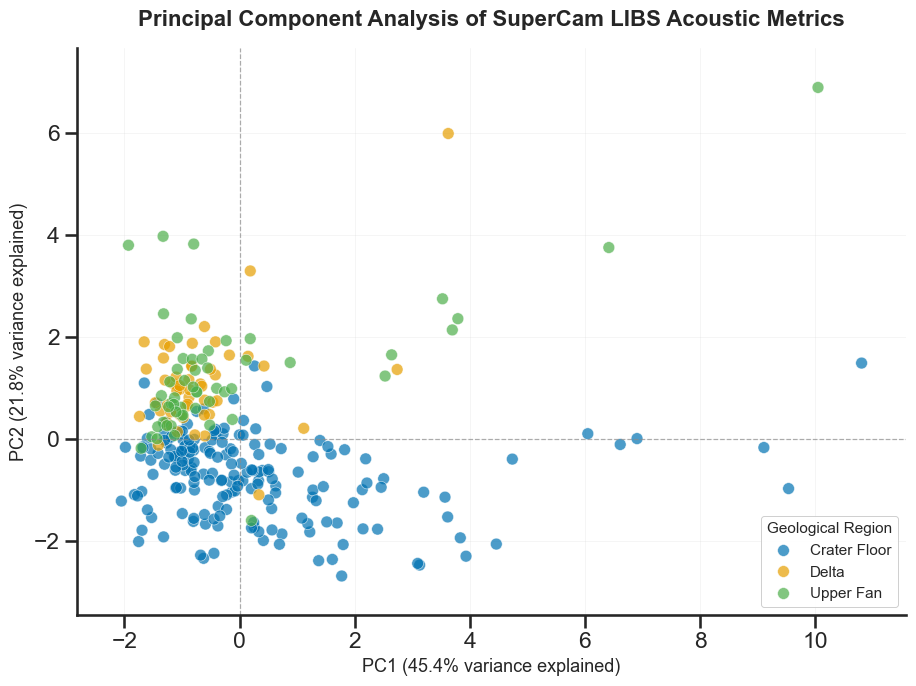

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------------------------
# Metrics and plotting order
# -------------------------------------------------

metrics = [
    "Slope (dB/s)",
    "C2 (dB)",
    "Spectral Centroid (Hz)",
    "Spectral Bandwidth (Hz)",
    "Peak Frequency (Hz)",
    "Rolloff 85% (Hz)",
    "High Frequency Fraction",
    "High/Low Ratio"
]

region_order = ["Crater Floor", "Delta", "Upper Fan"]

palette = {
    "Crater Floor": "#0072B2",
    "Delta": "#E69F00",
    "Upper Fan": "#4DAF4A"
}
# -------------------------------------------------
# Prepare PCA
# -------------------------------------------------

analysis_df = (
    df[["Region"] + metrics]
    .dropna()
    .copy()
)

X_scaled = StandardScaler().fit_transform(
    analysis_df[metrics]
)

pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": scores[:, 0],
    "PC2": scores[:, 1],
    "Region": analysis_df["Region"].values
})

pc1_variance = 100 * pca.explained_variance_ratio_[0]
pc2_variance = 100 * pca.explained_variance_ratio_[1]

# -------------------------------------------------
# Plot
# -------------------------------------------------

sns.set_theme(
    context="talk",
    style="ticks"
)

fig, ax = plt.subplots(figsize=(9.5, 7.2))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Region",
    hue_order=region_order,
    palette=palette,
    s=72,
    alpha=0.70,
    edgecolor="white",
    linewidth=0.45,
    ax=ax
)


# Light reference lines
ax.axhline(
    0,
    color="0.55",
    linestyle="--",
    linewidth=0.9,
    alpha=0.7
)

ax.axvline(
    0,
    color="0.55",
    linestyle="--",
    linewidth=0.9,
    alpha=0.7
)

# Add padding so points are not clipped
x_range = plot_df["PC1"].max() - plot_df["PC1"].min()
y_range = plot_df["PC2"].max() - plot_df["PC2"].min()

ax.set_xlim(
    plot_df["PC1"].min() - 0.06 * x_range,
    plot_df["PC1"].max() + 0.06 * x_range
)

ax.set_ylim(
    plot_df["PC2"].min() - 0.08 * y_range,
    plot_df["PC2"].max() + 0.08 * y_range
)

# Labels and title
ax.set_xlabel(
    f"PC1 ({pc1_variance:.1f}% variance explained)",
    fontsize=13
)

ax.set_ylabel(
    f"PC2 ({pc2_variance:.1f}% variance explained)",
    fontsize=13
)

ax.set_title(
    "Principal Component Analysis of SuperCam LIBS Acoustic Metrics",
    fontsize=16,
    weight="bold",
    pad=16
)

# Clean legend
legend = ax.legend(
    title="Geological Region",
    frameon=True,
    loc="lower right",
    fontsize=11,
    title_fontsize=11
)

legend.get_frame().set_alpha(0.95)
legend.get_frame().set_linewidth(0.7)

# Subtle grid and cleaner frame
ax.grid(
    True,
    linewidth=0.6,
    alpha=0.22
)

sns.despine(ax=ax)

plt.tight_layout()

# High-resolution export
plt.savefig(
    "PCA_SuperCam_LIBS_Acoustic_Metrics.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

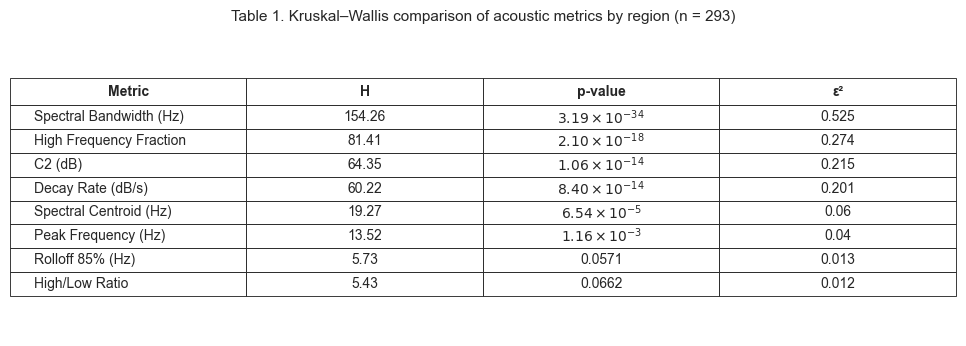

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Table data
table_df = pd.DataFrame({
    "Metric": [
        "Spectral Bandwidth (Hz)",
        "High Frequency Fraction",
        "C2 (dB)",
        "Decay Rate (dB/s)",
        "Spectral Centroid (Hz)",
        "Peak Frequency (Hz)",
        "Rolloff 85% (Hz)",
        "High/Low Ratio"
    ],
    "H": [154.26, 81.41, 64.35, 60.22, 19.27, 13.52, 5.73, 5.43],
    "p-value": [
        r"$3.19 \times 10^{-34}$",
        r"$2.10 \times 10^{-18}$",
        r"$1.06 \times 10^{-14}$",
        r"$8.40 \times 10^{-14}$",
        r"$6.54 \times 10^{-5}$",
        r"$1.16 \times 10^{-3}$",
        "0.0571",
        "0.0662"
    ]
    ,
    "ε²": [0.525, 0.274, 0.215, 0.201, 0.060, 0.040, 0.013, 0.012]
})

# Create figure
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.axis("off")

# Build table
tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

# Formatting
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.4)

# Header styling
for (row, col), cell in tbl.get_celld().items():
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(cell.get_height() * 1.15)

# Left-align metric names
for i in range(1, len(table_df) + 1):
    tbl[(i, 0)].get_text().set_ha("left")

# Title / caption
plt.title(
    "Table 1. Kruskal–Wallis comparison of acoustic metrics by region (n = 293)",
    fontsize=11,
    pad=12
)

plt.tight_layout()

# Save high-res image
plt.savefig(
    "Kruskal_Wallis_Table.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

C:\Users\cmkua\AppData\Local\Temp\ipykernel_3200\3118835306.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\cmkua\AppData\Local\Temp\ipykernel_3200\3118835306.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\cmkua\AppData\Local\Temp\ipykernel_3200\3118835306.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\cmkua\AppData\Local\Temp\ipykernel_3200\3118835306.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


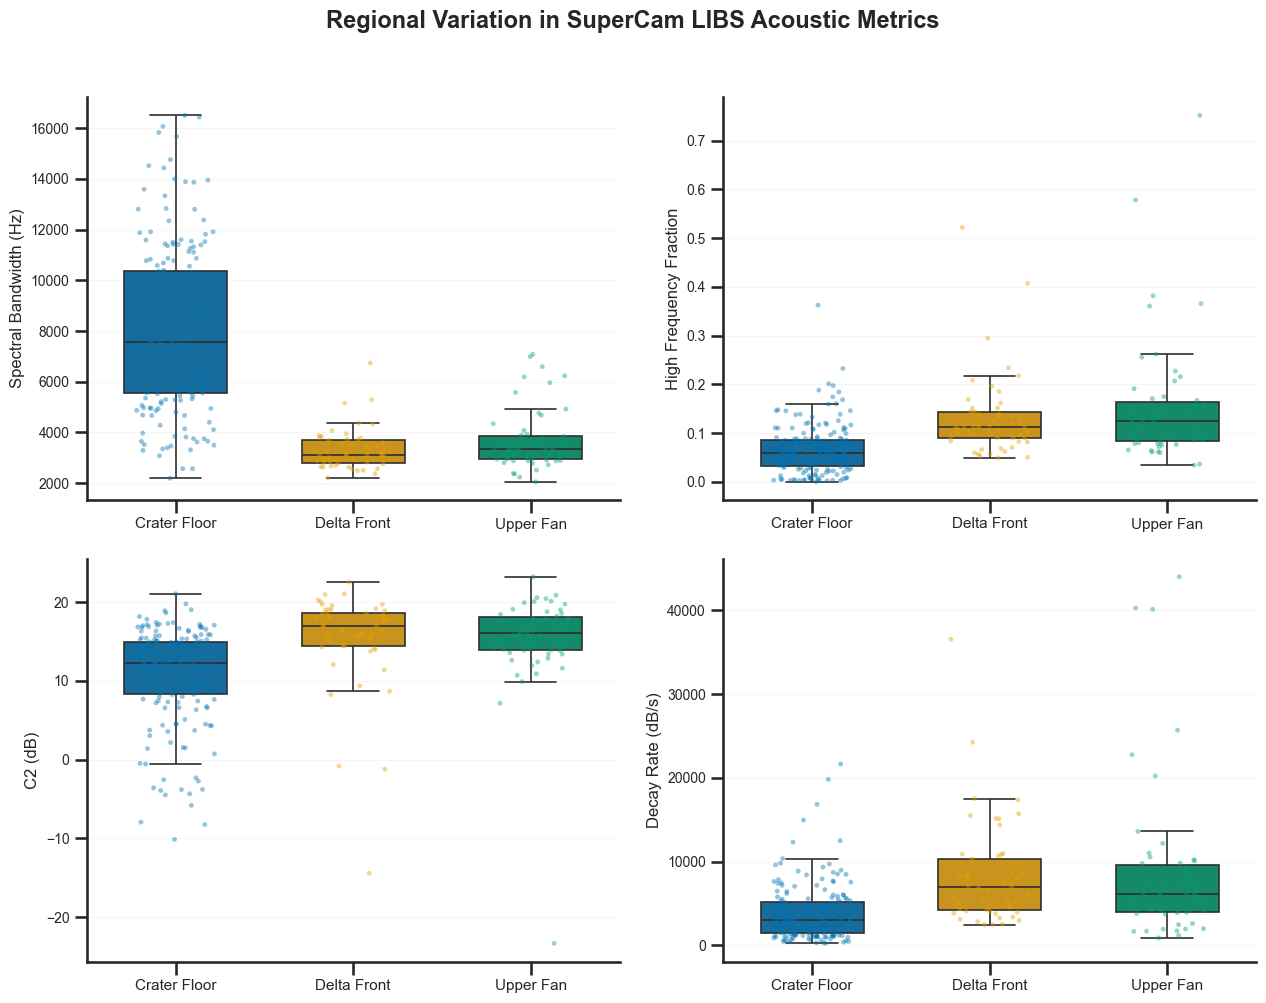

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# Prepare plotting dataframe
# -------------------------------------------------

plot_df = df.copy()

# Report decay rate as -slope so larger values = faster decay
plot_df["Decay Rate (dB/s)"] = -plot_df["Slope (dB/s)"]

region_order = ["Crater Floor", "Delta", "Upper Fan"]

palette = {
    "Crater Floor": "#0072B2",
    "Delta": "#E69F00",
    "Upper Fan": "#009E73"
}

metrics_to_plot = [
    ("Spectral Bandwidth (Hz)", "Spectral Bandwidth (Hz)"),
    ("High Frequency Fraction", "High Frequency Fraction"),
    ("C2 (dB)", "C2 (dB)"),
    ("Decay Rate (dB/s)", "Decay Rate (dB/s)")
]

# -------------------------------------------------
# Plot
# -------------------------------------------------

sns.set_theme(
    context="talk",
    style="ticks"
)

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 10)
)

axes = axes.flatten()

for ax, (column, ylabel) in zip(axes, metrics_to_plot):

    data = plot_df[["Region", column]].dropna()

    # Boxplot
    sns.boxplot(
        data=data,
        x="Region",
        y=column,
        order=region_order,
        hue="Region",
        hue_order=region_order,
        palette=palette,
        width=0.58,
        showfliers=False,
        linewidth=1.2,
        legend=False,
        ax=ax
    )

    # Individual observations
    sns.stripplot(
        data=data,
        x="Region",
        y=column,
        order=region_order,
        hue="Region",
        hue_order=region_order,
        palette=palette,
        jitter=0.22,
        size=3.5,
        alpha=0.42,
        linewidth=0,
        legend=False,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=12)

    # Display "Delta Front" without changing df
    ax.set_xticklabels(
        ["Crater Floor", "Delta Front", "Upper Fan"],
        fontsize=11
    )

    ax.tick_params(axis="y", labelsize=10)

    ax.grid(
        axis="y",
        linewidth=0.6,
        alpha=0.22
    )

    sns.despine(ax=ax)

fig.suptitle(
    "Regional Variation in SuperCam LIBS Acoustic Metrics",
    fontsize=17,
    weight="bold",
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "Regional_Acoustic_Metrics.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()